# Actor Co-Appearance Network — Complex Networks Project (Part 2)

**Real-data analysis.** Nodes are film actors; an edge connects two actors who
appeared in the same movie. Data is an OMDb-style export of the top few thousand
IMDB movies.

Following the project requirements, we analyse **three networks side by side**:

1. **Real** — the actor co-appearance network built from the data.
2. **Random (Erdős–Rényi)** — same number of nodes, similar number of links.
3. **Scale-free (Barabási–Albert)** — same number of nodes, similar number of links.

For each network we compute the required properties, plot the four required
distributions (degree, clustering, betweenness, component size), visualise the
network, identify the most important nodes, and finally classify what *type* of
network the real one is.

**Pipeline**
1. Load & clean the data
2. Build the actor network (bipartite movie–actor graph → actor projection)
3. Build the ER and BA reference networks
4. Network properties — comparison table across all three
5. The four distribution plots — for each network
6. Network visualisation — inline
7. Most important nodes — centrality measures
8. Community detection — recovering cast groups
9. Path lengths & small-world test
10. Classification — what type of network is this?

> **Data note.** OMDb's `Actors` field lists only the ~3–4 top-billed actors per
> film. An edge therefore means a *top-billed co-starring* relationship, which keeps
> the graph sparse and meaningful — but deep-bench franchise actors may be absent.
> State this as a limitation in the report.


## 0. Setup

In [1]:
# Run once if needed:
# !pip install pandas networkx python-louvain matplotlib numpy

import ast
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import community as community_louvain  # python-louvain
    HAS_LOUVAIN = True
except ImportError:
    HAS_LOUVAIN = False
    print("python-louvain not found - will fall back to greedy modularity.")

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (9, 6)
RNG_SEED = 42
print("networkx", nx.__version__, "| pandas", pd.__version__)


python-louvain not found - will fall back to greedy modularity.
networkx 3.5 | pandas 2.3.3


## 1. Load & clean the data

Set `CSV_PATH` to your file. `sep=None` auto-detects tab vs comma separators.


In [3]:
CSV_PATH = "./full_movie_data.csv"   # <-- change to your file path

df = pd.read_csv(CSV_PATH, sep=None, engine="python")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
df.head(3)


Loaded 2999 rows, 25 columns


,Title,Year,Rated,Released,Runtime,Genre,Director,Writer,Actors,Plot,...,Metascore,imdbRating,imdbVotes,imdbID,Type,DVD,BoxOffice,Production,Website,Response
0,The Shawshank Redemption,1994,R,14 Oct 1994,142 min,Drama,Frank Darabont,"Stephen King, Frank Darabont","Tim Robbins, Morgan Freeman, Bob Gunton",A wrongfully convicted banker forms a close fr...,...,82.0,9.3,"3,182,645",tt0111161,movie,NaN,"$28,767,189",NaN,NaN,True
1,The Dark Knight,2008,PG-13,18 Jul 2008,152 min,"Action, Crime, Drama",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer","Christian Bale, Heath Ledger, Aaron Eckhart",When a menace known as the Joker wreaks havoc ...,...,85.0,9.1,"3,161,907",tt0468569,movie,NaN,"$534,987,076",NaN,NaN,True
2,Inception,2010,PG-13,16 Jul 2010,148 min,"Action, Adventure, Sci-Fi",Christopher Nolan,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",A thief who steals corporate secrets through t...,...,74.0,8.8,"2,811,614",tt1375666,movie,NaN,"$292,587,330",NaN,NaN,True


In [4]:
# Keep only what we need; drop unusable rows.
keep = [c for c in ["Title", "Year", "Genre", "imdbRating", "imdbID", "Actors"]
        if c in df.columns]
df = df[keep].copy()

df["Actors"] = df["Actors"].replace("N/A", np.nan)      # OMDb missing marker
df = df.dropna(subset=["Actors", "Title"])
subset = ["Title", "Year"] if "Year" in df.columns else ["Title"]
df = df.drop_duplicates(subset=subset)
print(f"{len(df)} movies remain after cleaning")


2999 movies remain after cleaning


In [5]:
def parse_actors(cell):
    """Split the comma-separated Actors string into a clean list of names."""
    names = [a.strip() for a in str(cell).split(",")]
    return [n for n in names if n and n.lower() != "n/a"]

df["actor_list"] = df["Actors"].apply(parse_actors)
df = df[df["actor_list"].map(len) >= 2].reset_index(drop=True)   # need >=2 for an edge

all_actors = [a for lst in df["actor_list"] for a in lst]
print(f"{len(df)} movies | {len(all_actors)} actor-credits | "
      f"{len(set(all_actors))} unique actors")
print("Most-credited actors:", Counter(all_actors).most_common(5))


2998 movies | 8994 actor-credits | 3446 unique actors
Most-credited actors: [('Robert De Niro', 43), ('Tom Hanks', 41), ('Tom Cruise', 35), ('Brad Pitt', 34), ('Matt Damon', 33)]


## 2. Build the actor network

The raw data is a **bipartite** movie–actor graph (edges only run movie↔actor).
The network we want for analysis is the **one-mode actor projection**: drop the
movie nodes, and connect two actors directly if they shared a movie. The projected
edge weight = number of shared films.


In [6]:
from networkx.algorithms import bipartite

B = nx.Graph()
for idx, row in df.iterrows():
    m = f"MOVIE::{idx}::{row['Title']}"          # unique id per movie
    B.add_node(m, bipartite=0)
    for actor in row["actor_list"]:
        B.add_node(actor, bipartite=1)
        B.add_edge(m, actor)

actor_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == 1}
G_real = bipartite.weighted_projected_graph(B, actor_nodes)
print(f"Actor network: {G_real.number_of_nodes()} nodes, "
      f"{G_real.number_of_edges()} edges")


Actor network: 3446 nodes, 8375 edges


## 3. Build the reference networks (random & scale-free)

The requirements ask for two artificial networks built from the real one, with the
**same number of nodes** and a **similar number of links**:

- **Erdős–Rényi `G(n, m)`** — `n` nodes, exactly `m` edges placed uniformly at random.
- **Barabási–Albert** — grows by preferential attachment; each new node adds `m_ba`
  edges. Total edges ≈ `m_ba · (n − m_ba)`, so we pick `m_ba` to match the real
  edge count as closely as possible.

> **Expected divergence (worth discussing in the report).** BA is connected by
> construction and ER is *almost* surely connected at this density, whereas the real
> network is fragmented into many components. ER has a Poisson degree distribution
> with low clustering; BA is scale-free with low clustering; the real network is
> expected to be scale-free *and* highly clustered. Those mismatches are the insight.


In [7]:
n = G_real.number_of_nodes()
m = G_real.number_of_edges()

# Erdos-Renyi: same n, exactly m edges.
G_er = nx.gnm_random_graph(n, m, seed=RNG_SEED)

# Barabasi-Albert: choose m_ba so total edges ~ m.
# edges(BA) = m_ba * (n - m_ba)  ->  solve for m_ba, take nearest valid integer.
m_ba = max(1, round((n - np.sqrt(max(n*n - 4*m, 0))) / 2))
G_ba = nx.barabasi_albert_graph(n, m_ba, seed=RNG_SEED)

print(f"Real : n={n:>6}  m={m:>7}")
print(f"ER   : n={G_er.number_of_nodes():>6}  m={G_er.number_of_edges():>7}")
print(f"BA   : n={G_ba.number_of_nodes():>6}  m={G_ba.number_of_edges():>7}  "
      f"(m_ba={m_ba})")

networks = {"Real": G_real, "Random (ER)": G_er, "Scale-free (BA)": G_ba}


Real : n=  3446  m=   8375
ER   : n=  3446  m=   8375
BA   : n=  3446  m=   6888  (m_ba=2)


## 4. Network properties — comparison table

For each network: number of nodes & links, min/max/average degree, number of
connected components and the size of the largest, diameter, and average clustering
coefficient. Diameter and average path length are only defined within a connected
graph, so they are measured on each network's **giant component (GC)**; for large
GCs the average path length is estimated by sampling source nodes.


In [8]:
def giant_component(G):
    """Return the largest connected component as a subgraph."""
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

def avg_path_length(G, sample=400, seed=RNG_SEED):
    """Exact for small graphs; sampled estimate for large ones."""
    if G.number_of_nodes() <= 1:
        return 0.0
    if G.number_of_nodes() <= 1500:
        return nx.average_shortest_path_length(G)
    rng = np.random.default_rng(seed)
    srcs = rng.choice(list(G.nodes()), size=min(sample, G.number_of_nodes()),
                      replace=False)
    lengths = []
    for s in srcs:
        lengths.extend(nx.single_source_shortest_path_length(G, s).values())
    return float(np.mean([l for l in lengths if l > 0]))

def describe(G):
    degs = [d for _, d in G.degree()]
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    gc = G.subgraph(comps[0]).copy()
    return {
        "nodes": G.number_of_nodes(),
        "links": G.number_of_edges(),
        "min degree": min(degs),
        "max degree": max(degs),
        "avg degree": round(np.mean(degs), 3),
        "components": len(comps),
        "largest comp": len(comps[0]),
        "largest comp %": round(100 * len(comps[0]) / G.number_of_nodes(), 1),
        "avg clustering": round(nx.average_clustering(G), 4),
        "GC diameter": nx.diameter(gc) if gc.number_of_nodes() <= 1500 else "n/a (large)",
        "GC avg path": round(avg_path_length(gc), 3),
    }

properties = pd.DataFrame({name: describe(G) for name, G in networks.items()})
properties


,Real,Random (ER),Scale-free (BA)
nodes,3446,3446,3446
links,8375,8375,6888
min degree,2,0,2
max degree,77,13,160
avg degree,4.861,4.861,3.998
components,213,28,1
largest comp,2692,3419,3446
largest comp %,78.1,99.2,100.0
avg clustering,0.7198,0.0009,0.0103
GC diameter,n/a (large),n/a (large),n/a (large)


In [9]:
# Cache each giant component - reused by later sections.
GC = {name: giant_component(G) for name, G in networks.items()}
for name, g in GC.items():
    print(f"{name:18} GC: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")


Real               GC: 2692 nodes, 7558 edges
Random (ER)        GC: 3419 nodes, 8375 edges
Scale-free (BA)    GC: 3446 nodes, 6888 edges


## 5. The four required distributions

For each network we plot: **degree distribution** (log–log, to expose a power law),
**clustering-coefficient distribution**, **betweenness-centrality distribution**, and
**connected-components size distribution**. Betweenness is sampled (`k` pivots) for
speed on large graphs.


In [10]:
def betweenness(G, k=400, seed=RNG_SEED):
    k = min(k, G.number_of_nodes())
    return nx.betweenness_centrality(G, k=k, seed=seed)

# Pre-compute betweenness on each giant component (reused in section 7).
betw = {name: betweenness(g) for name, g in GC.items()}
print("Betweenness computed for all three giant components.")


Betweenness computed for all three giant components.


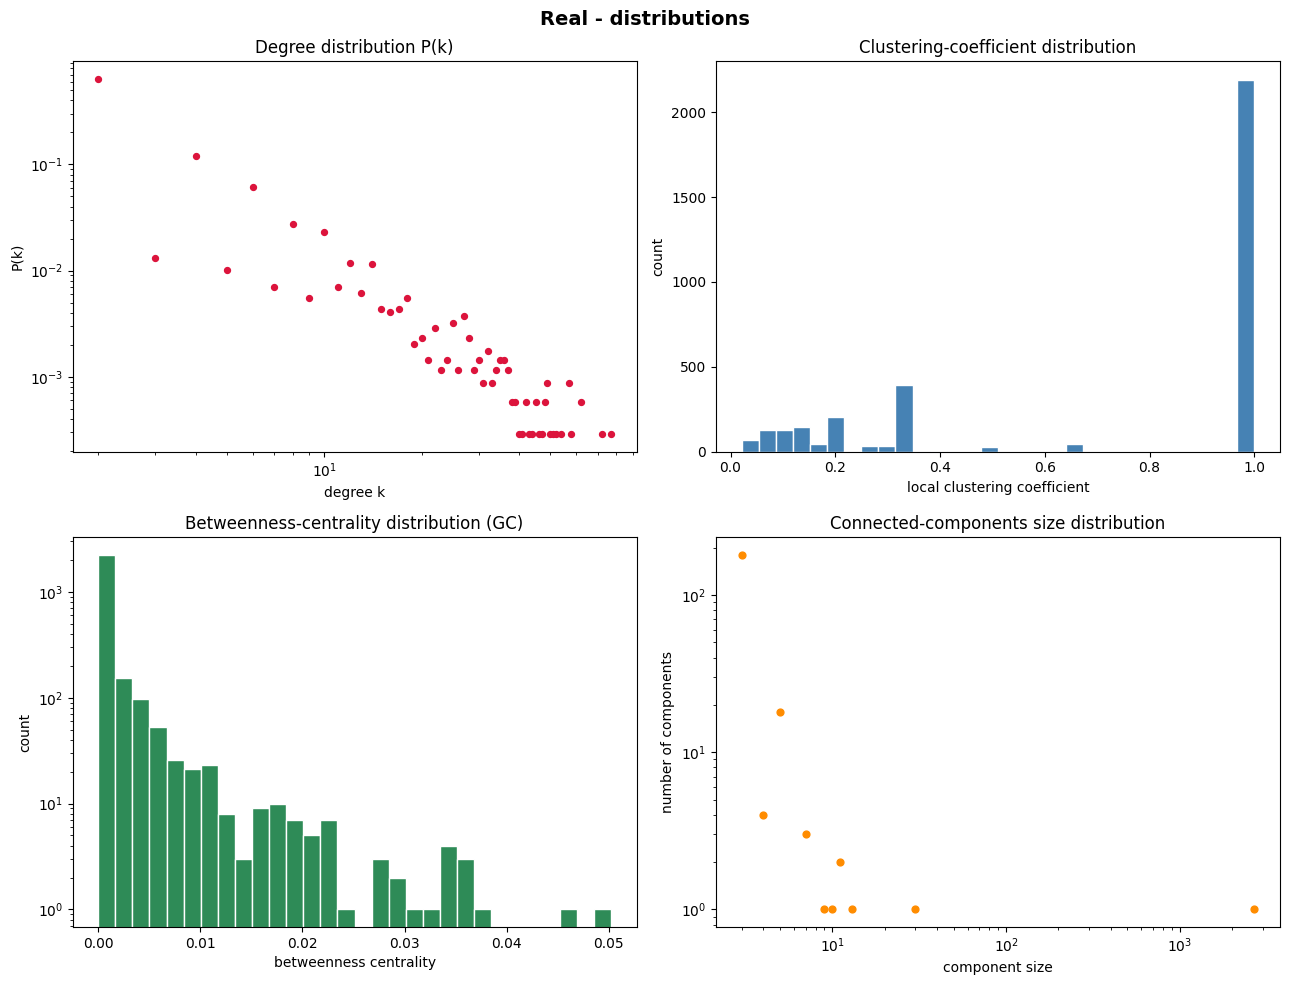

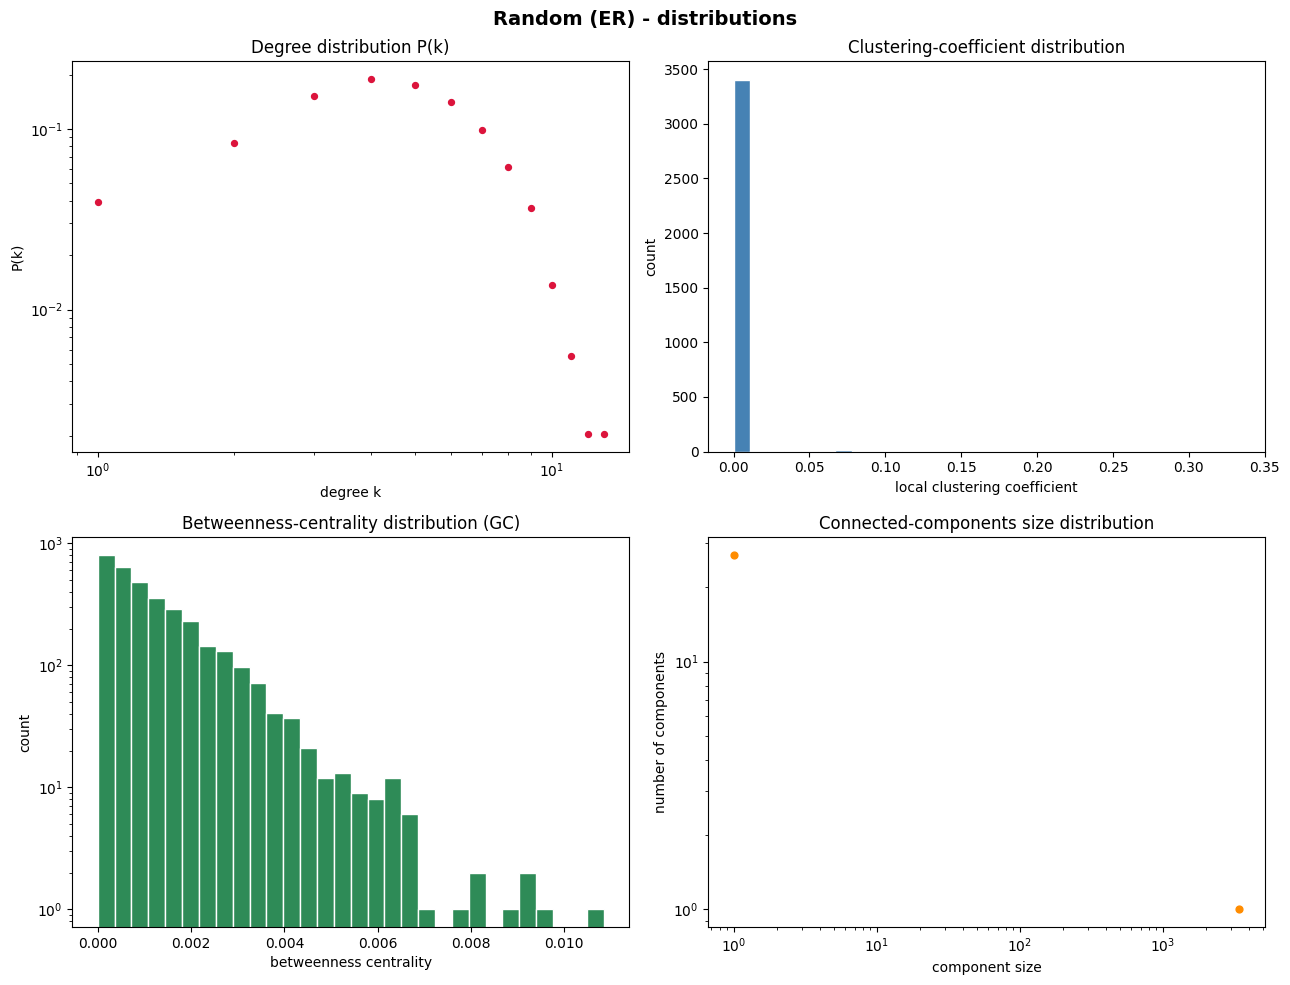

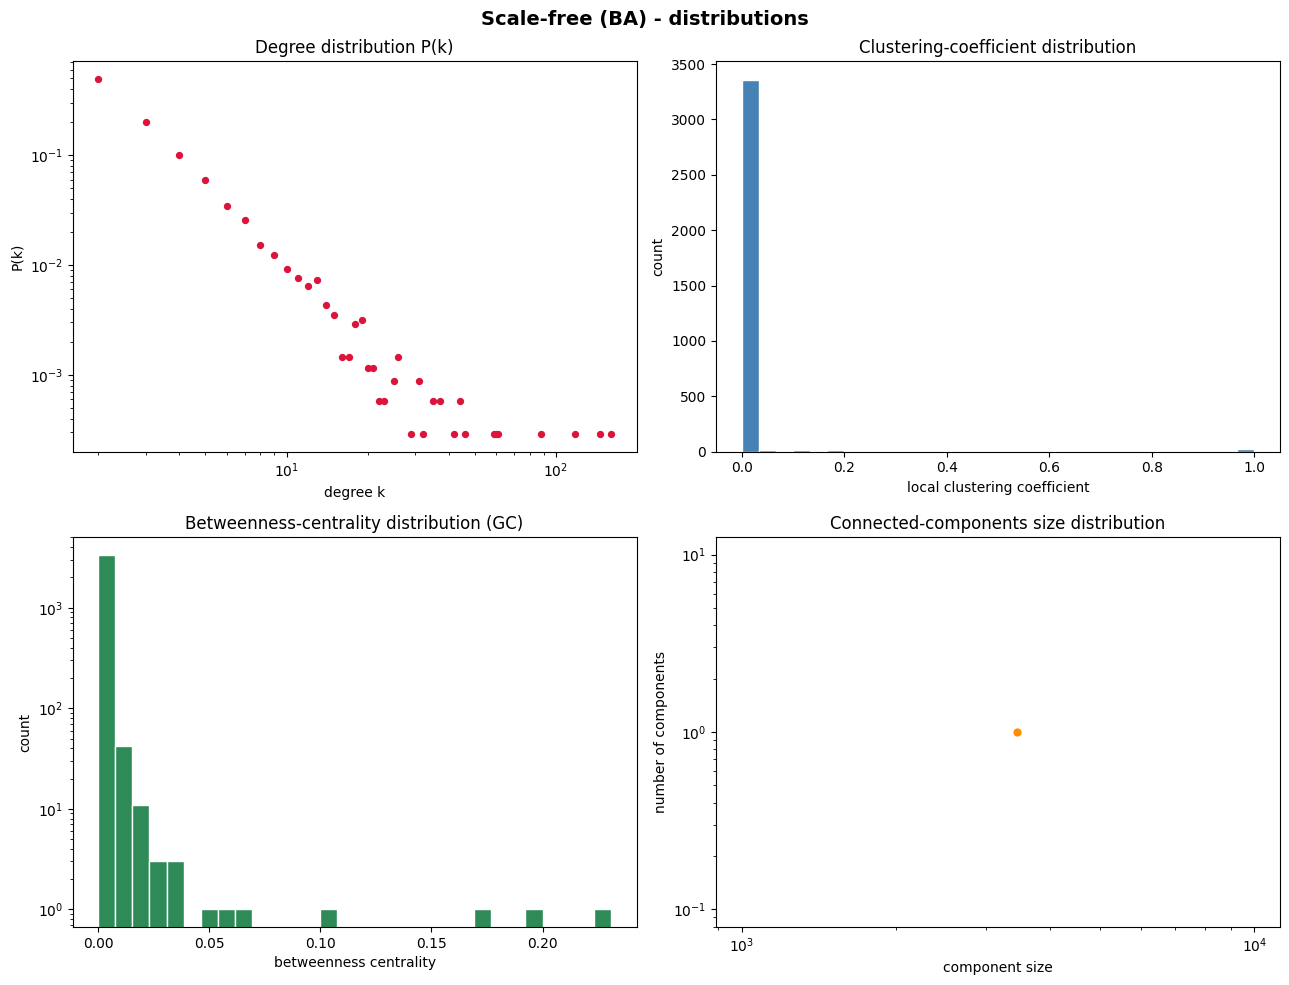

In [11]:
def plot_distributions(name, G, gc, betw_gc):
    fig, ax = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(f"{name} - distributions", fontsize=14, fontweight="bold")

    # (1) Degree distribution, log-log.
    degs = [d for _, d in G.degree()]
    cnt = Counter(degs)
    ks = np.array(sorted(k for k in cnt if k > 0))
    pk = np.array([cnt[k] for k in ks], float); pk /= pk.sum()
    ax[0,0].scatter(ks, pk, s=18, color="crimson")
    ax[0,0].set(xscale="log", yscale="log", title="Degree distribution P(k)",
                xlabel="degree k", ylabel="P(k)")

    # (2) Clustering-coefficient distribution.
    cc = list(nx.clustering(G).values())
    ax[0,1].hist(cc, bins=30, color="steelblue", edgecolor="white")
    ax[0,1].set(title="Clustering-coefficient distribution",
                xlabel="local clustering coefficient", ylabel="count")

    # (3) Betweenness-centrality distribution (giant component).
    ax[1,0].hist(list(betw_gc.values()), bins=30, color="seagreen",
                 edgecolor="white")
    ax[1,0].set(title="Betweenness-centrality distribution (GC)",
                xlabel="betweenness centrality", ylabel="count", yscale="log")

    # (4) Connected-components size distribution.
    sizes = [len(c) for c in nx.connected_components(G)]
    scnt = Counter(sizes)
    sx = sorted(scnt)
    ax[1,1].scatter(sx, [scnt[s] for s in sx], s=24, color="darkorange")
    ax[1,1].set(title="Connected-components size distribution",
                xlabel="component size", ylabel="number of components",
                xscale="log", yscale="log")

    plt.tight_layout(); plt.show()

for name, G in networks.items():
    plot_distributions(name, G, GC[name], betw[name])


## 6. Network visualisation

Drawn inline with matplotlib. For large graphs, plotting every node is unreadable,
so we visualise each network's **giant component**, and if that is still very large
we draw a representative sample subgraph. The real network is coloured by community
(computed in section 8 and revisited there with full colouring).


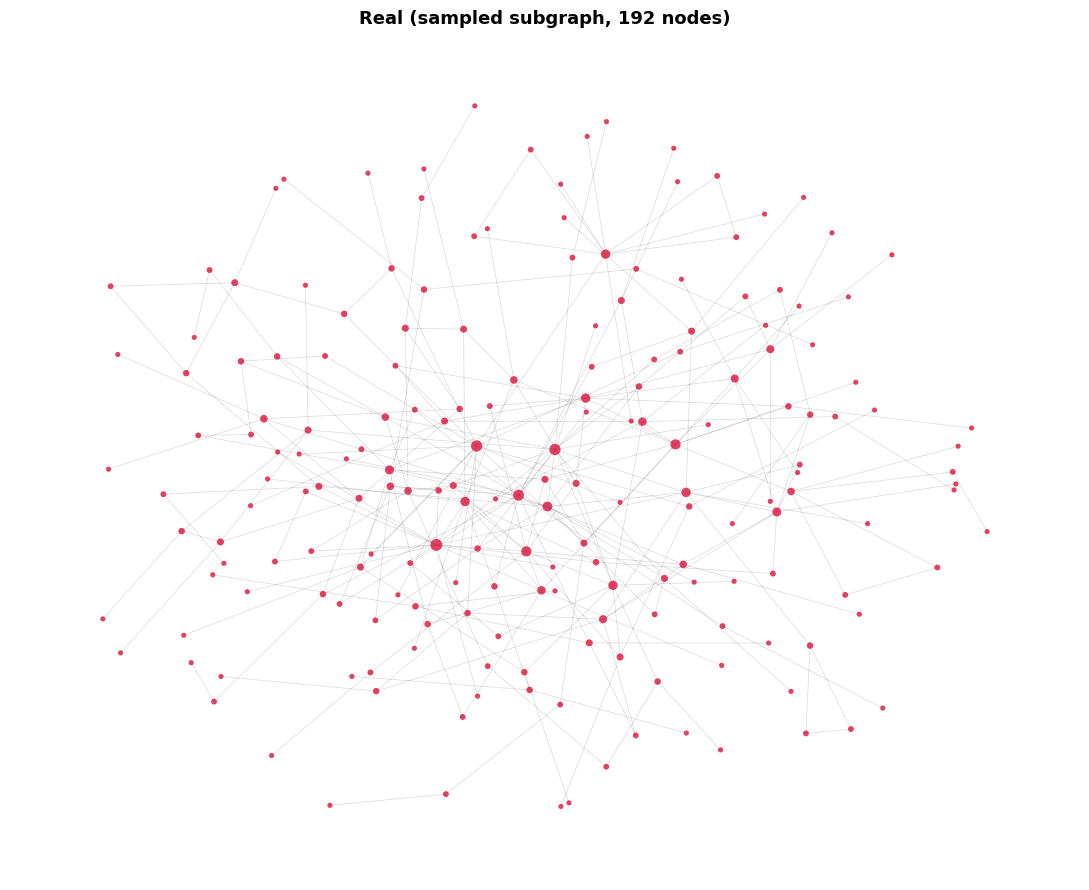

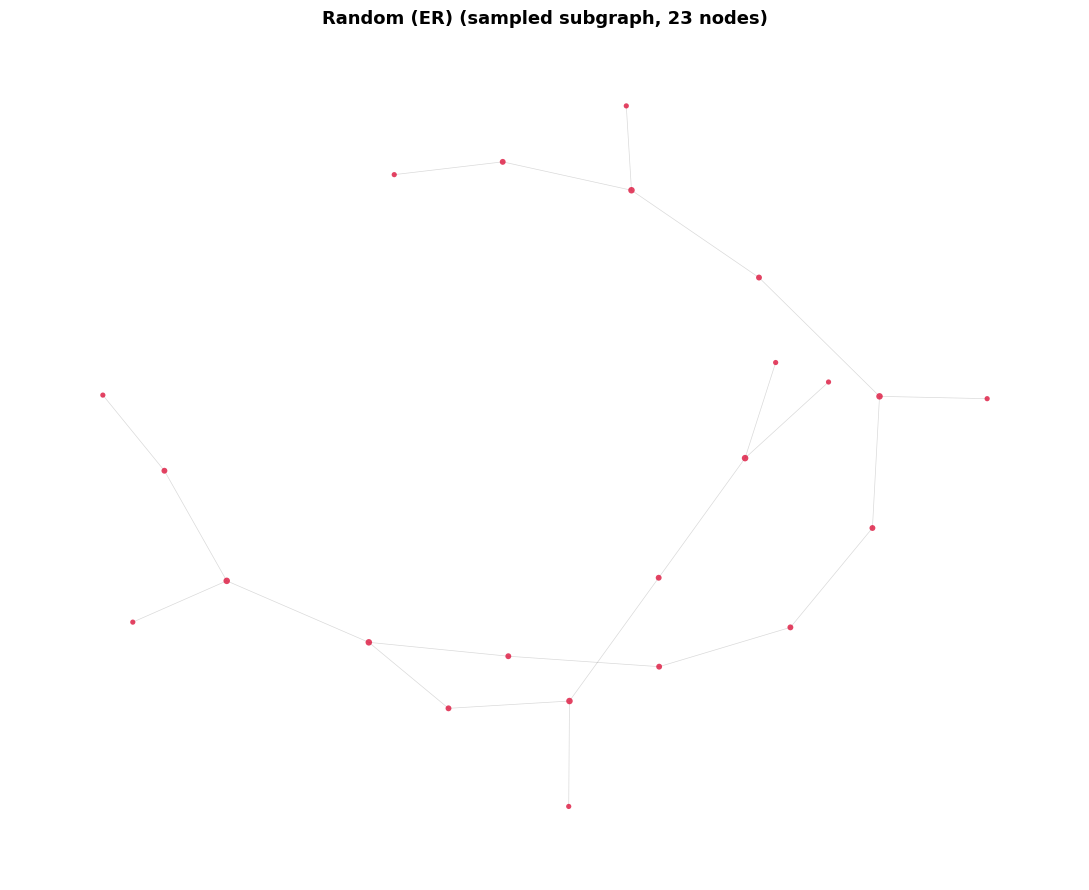

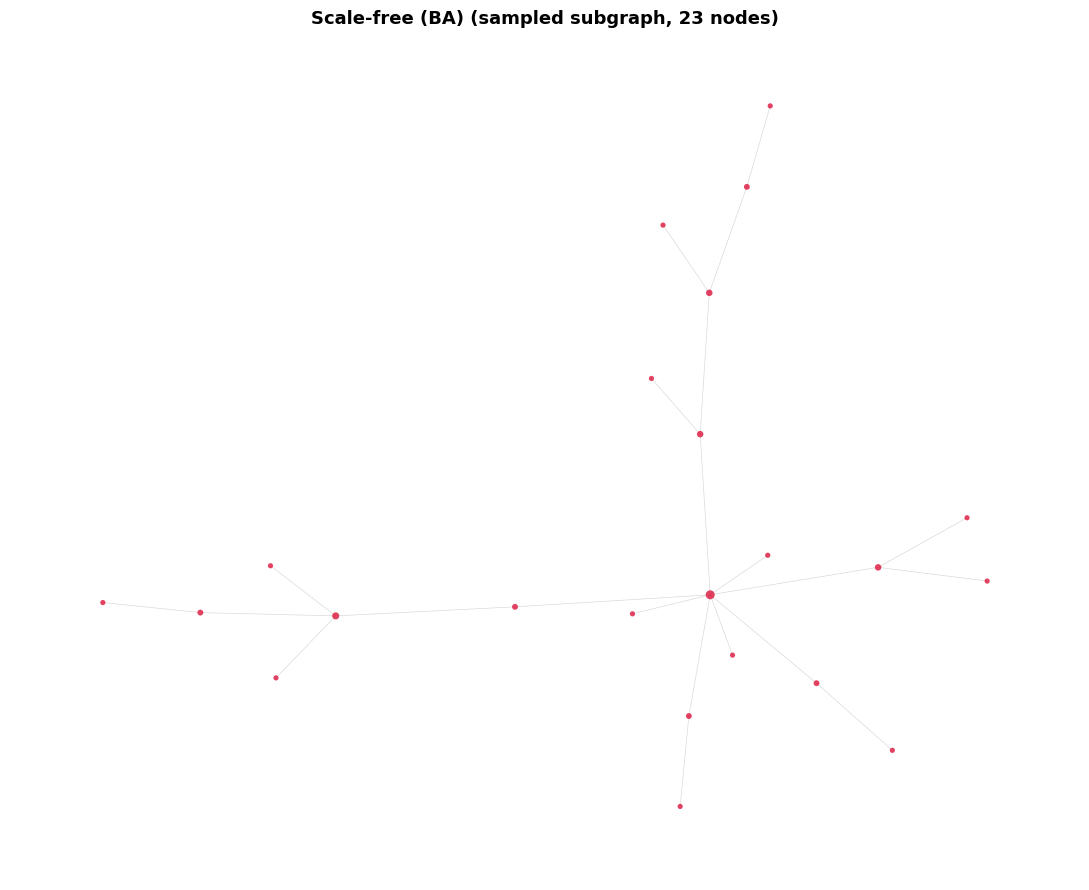

In [12]:
def draw_network(name, G, max_nodes=600, seed=RNG_SEED):
    g = G
    if g.number_of_nodes() > max_nodes:
        rng = np.random.default_rng(seed)
        keep = set(rng.choice(list(g.nodes()), size=max_nodes, replace=False))
        g = g.subgraph(keep).copy()
        g = g.subgraph(max(nx.connected_components(g), key=len)).copy()
        note = f" (sampled subgraph, {g.number_of_nodes()} nodes)"
    else:
        note = f" ({g.number_of_nodes()} nodes)"

    pos = nx.spring_layout(g, seed=seed, k=0.3)
    degs = dict(g.degree())
    sizes = [10 + 4 * degs[n] for n in g.nodes()]
    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(g, pos, alpha=0.15, width=0.5)
    nx.draw_networkx_nodes(g, pos, node_size=sizes, node_color="crimson",
                           alpha=0.8, linewidths=0)
    plt.title(f"{name}{note}", fontsize=13, fontweight="bold")
    plt.axis("off"); plt.tight_layout(); plt.show()

for name, G in networks.items():
    draw_network(name, GC[name])


## 7. Most important nodes — centrality measures

Four complementary measures, computed on each network's giant component. They
answer different questions; the divergence between them is itself a finding.

| Measure | High score means... |
|---|---|
| **Degree** | many distinct co-stars — prolific |
| **Betweenness** | a *bridge* between otherwise-separate film worlds |
| **Closeness** | able to reach the rest of the network in few steps |
| **Eigenvector** | embedded in the dense, well-connected core |


In [13]:
def centrality_table(g, betw_gc):
    deg = dict(g.degree())
    clo = nx.closeness_centrality(g)
    try:
        eig = nx.eigenvector_centrality(g, max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eig = nx.eigenvector_centrality_numpy(g)
    t = pd.DataFrame({"degree": deg, "betweenness": betw_gc,
                      "closeness": clo, "eigenvector": eig})
    t.index.name = "node"
    return t

cent = {name: centrality_table(GC[name], betw[name]) for name in networks}

# Show the top actors in the REAL network by each measure.
real_cent = cent["Real"]
for measure in ["degree", "betweenness", "closeness", "eigenvector"]:
    print(f"\n=== Real network - top 10 by {measure.upper()} ===")
    top = real_cent.sort_values(measure, ascending=False).head(10)[[measure]]
    print(top.round(4).to_string())



=== Real network - top 10 by DEGREE ===
                   degree
node                     
Tom Hanks              77
Robert De Niro         72
Nicolas Cage           62
Tom Cruise             62
Brad Pitt              58
Matt Damon             57
Johnny Depp            57
Mark Wahlberg          57
Denzel Washington      54
Ryan Reynolds          52

=== Real network - top 10 by BETWEENNESS ===
                 betweenness
node                        
Tom Hanks             0.0502
Robert De Niro        0.0458
Brad Pitt             0.0370
Morgan Freeman        0.0367
Jason Statham         0.0362
Lauren Bacall         0.0354
Humphrey Bogart       0.0349
Mark Wahlberg         0.0337
Nicole Kidman         0.0335
Tom Cruise            0.0335

=== Real network - top 10 by CLOSENESS ===
                    closeness
node                         
Robert De Niro         0.3268
Matt Damon             0.3256
Brad Pitt              0.3231
Morgan Freeman         0.3214
Meryl Streep           0.3194

In [14]:
# Most important node per measure, for all three networks (comparison).
rows = []
for name in networks:
    for measure in ["degree", "betweenness", "closeness", "eigenvector"]:
        top_node = cent[name][measure].idxmax()
        rows.append({"network": name, "measure": measure,
                     "top node": top_node,
                     "value": round(cent[name][measure].max(), 4)})
pd.DataFrame(rows)


,network,measure,top node,value
0,Real,degree,Tom Hanks,77.0000
1,Real,betweenness,Tom Hanks,0.0502
2,Real,closeness,Robert De Niro,0.3268
3,Real,eigenvector,Robert De Niro,0.1635
4,Random (ER),degree,381,13.0000
5,Random (ER),betweenness,2828,0.0108
6,Random (ER),closeness,2852,0.2245
7,Random (ER),eigenvector,2852,0.0771
8,Scale-free (BA),degree,0,160.0000
9,Scale-free (BA),betweenness,0,0.2308


## 8. Community detection — recovering cast groups

We use the **Louvain** method (modularity maximisation, weighted by shared films) on
the real network's giant component. **Modularity** measures how cleanly the network
splits into groups.

**Expected:** the real network should split into many well-separated communities
(franchise clusters, national cinemas) and score high modularity. The ER graph,
having no community structure by construction, should score much lower. BA, also
built without planted communities, should score low to moderate.


In [15]:
def detect_communities(g):
    if HAS_LOUVAIN:
        part = community_louvain.best_partition(g, weight="weight",
                                                random_state=RNG_SEED)
        mod = community_louvain.modularity(part, g, weight="weight")
        method = "Louvain"
    else:
        coms = nx.community.greedy_modularity_communities(g, weight="weight")
        part = {n: i for i, c in enumerate(coms) for n in c}
        mod = nx.community.modularity(g, [set(c) for c in coms], weight="weight")
        method = "greedy modularity"
    return part, mod, method

part_real, mod_real, method = detect_communities(GC["Real"])
sizes = Counter(part_real.values())
print(f"Real network ({method}): {len(sizes)} communities | "
      f"modularity = {mod_real:.3f}")
print("Largest communities (size):", sizes.most_common(8))

# Modularity of the reference networks, for comparison.
for name in ["Random (ER)", "Scale-free (BA)"]:
    _, mod, _ = detect_communities(GC[name])
    print(f"{name}: modularity = {mod:.3f}")


Real network (greedy modularity): 47 communities | modularity = 0.536
Largest communities (size): [(0, 307), (1, 305), (2, 285), (3, 281), (4, 240), (5, 189), (6, 165), (7, 140)]
Random (ER): modularity = 0.448
Scale-free (BA): modularity = 0.530


In [16]:
# Name the biggest communities by their most-central members.
real_cent = cent["Real"]
for cid, _ in Counter(part_real.values()).most_common(8):
    members = [n for n, c in part_real.items() if c == cid]
    sub = real_cent.loc[[m for m in members if m in real_cent.index]]
    key = sub.sort_values("degree", ascending=False).head(8).index
    print(f"\nCommunity {cid}  ({len(members)} actors)")
    print("  Key actors:", ", ".join(key))



Community 0  (307 actors)
  Key actors: Brad Pitt, Matt Damon, George Clooney, Leonardo DiCaprio, Jim Carrey, Meryl Streep, Ben Affleck, Julia Roberts

Community 1  (305 actors)
  Key actors: Robert De Niro, Morgan Freeman, Arnold Schwarzenegger, Mel Gibson, Al Pacino, Gerard Butler, Robin Williams, Sean Connery

Community 2  (285 actors)
  Key actors: Nicolas Cage, Mark Wahlberg, Christian Bale, Russell Crowe, Liam Neeson, Steve Carell, Ryan Gosling, Charlize Theron

Community 3  (281 actors)
  Key actors: Ryan Reynolds, Samuel L. Jackson, Bruce Willis, Will Smith, Jake Gyllenhaal, Scarlett Johansson, Matthew McConaughey, Ewan McGregor

Community 4  (240 actors)
  Key actors: Johnny Depp, Angelina Jolie, Hugh Jackman, Daniel Craig, Michael Fassbender, Jack Black, Keira Knightley, Joel Edgerton

Community 5  (189 actors)
  Key actors: Tom Cruise, Adam Sandler, Owen Wilson, Cameron Diaz, John Cusack, Ben Stiller, Eddie Murphy, Antonio Banderas

Community 6  (165 actors)
  Key actors: D

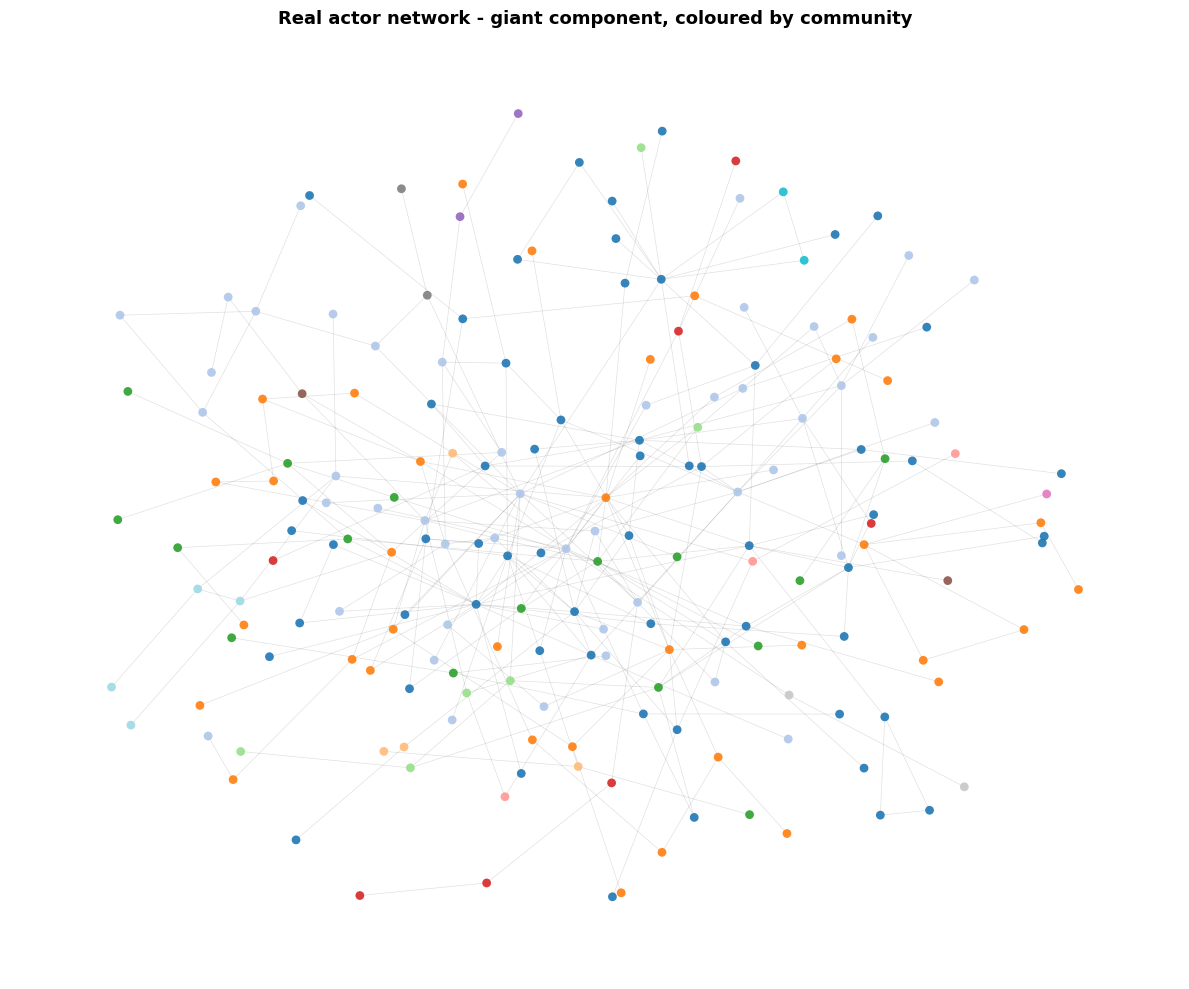

In [17]:
# Visualise the real giant component coloured by community.
g = GC["Real"]
if g.number_of_nodes() > 600:
    rng = np.random.default_rng(RNG_SEED)
    keep = set(rng.choice(list(g.nodes()), size=600, replace=False))
    g = g.subgraph(keep).copy()
    g = g.subgraph(max(nx.connected_components(g), key=len)).copy()

pos = nx.spring_layout(g, seed=RNG_SEED, k=0.3)
colors = [part_real.get(n, 0) for n in g.nodes()]
plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(g, pos, alpha=0.12, width=0.5)
nx.draw_networkx_nodes(g, pos, node_color=colors, cmap="tab20",
                       node_size=40, alpha=0.9, linewidths=0)
plt.title("Real actor network - giant component, coloured by community",
          fontsize=13, fontweight="bold")
plt.axis("off"); plt.tight_layout(); plt.show()


## 9. Path lengths & small-world test

A network is **small-world** if its average path length is close to that of an
equivalent random graph, while its clustering coefficient is far higher. The ER
network *is* the random baseline. We compute the small-world ratio
σ = (C/C_rand) / (L/L_rand); σ ≫ 1 indicates small-world structure.


In [18]:
C_real = nx.average_clustering(GC["Real"])
L_real = avg_path_length(GC["Real"])
C_rand = nx.average_clustering(GC["Random (ER)"])
L_rand = avg_path_length(GC["Random (ER)"])

print(f"{'':22}{'Real':>12}{'Random (ER)':>14}")
print(f"{'avg clustering':22}{C_real:>12.4f}{C_rand:>14.4f}")
print(f"{'avg path length':22}{L_real:>12.3f}{L_rand:>14.3f}")

sigma = (C_real / C_rand) / (L_real / L_rand) if C_rand > 0 and L_rand > 0 else float("nan")
print(f"\nSmall-world ratio sigma = {sigma:.1f}")
print("sigma >> 1  ->  small-world: short paths AND high clustering.")


                              Real   Random (ER)
avg clustering              0.6532        0.0009
avg path length              4.540         5.331

Small-world ratio sigma = 892.2
sigma >> 1  ->  small-world: short paths AND high clustering.


## 10. Classification — what type of network is this?

We pull the evidence together: the power-law fit of the degree distribution, the
small-world ratio, and the comparison against the ER and BA references, to state
what type of network the real actor network is.


In [19]:
verdict = []

# Power-law check on the real degree distribution.
try:
    import powerlaw
    fit = powerlaw.Fit([d for _, d in G_real.degree()],
                        discrete=True, verbose=False)
    R, p = fit.distribution_compare("power_law", "lognormal")
    gamma = fit.power_law.alpha
    verdict.append(f"Degree distribution: estimated power-law exponent gamma "
                   f"= {gamma:.2f} (x_min={fit.power_law.xmin}).")
    verdict.append(f"  power-law vs lognormal: R={R:.2f}, p={p:.3f} "
                   f"(R>0 favours power-law).")
    scale_free = (2 <= gamma <= 3.5) and R > 0
except ImportError:
    verdict.append("Install `powerlaw` for a rigorous exponent fit: "
                    "pip install powerlaw")
    scale_free = None

verdict.append(f"Small-world ratio sigma = {sigma:.1f} "
               f"({'small-world' if sigma > 1 else 'not small-world'}).")
verdict.append(f"Clustering: real={C_real:.4f} vs random={C_rand:.4f} "
               f"({'much higher than random' if C_real > 3*C_rand else 'comparable'}).")
verdict.append(f"Community modularity: real={mod_real:.3f} "
               f"(strong community structure if > ~0.3).")

print("EVIDENCE")
for v in verdict:
    print(" -", v)

print("\nCONCLUSION")
print("The real actor network shows the signature of a scale-free,")
print("small-world network with strong community structure: a heavy-tailed")
print("degree distribution unlike the Poisson ER graph, clustering far above")
print("random, short average paths, and high modularity. The BA graph")
print("reproduces the heavy tail but not the high clustering or communities;")
print("the ER graph reproduces neither. Interpret the printed numbers from")
print("your own data to confirm and refine this statement.")


EVIDENCE
 - Degree distribution: estimated power-law exponent gamma = 2.71 (x_min=10.0).
 -   power-law vs lognormal: R=-7.91, p=0.009 (R>0 favours power-law).
 - Small-world ratio sigma = 892.2 (small-world).
 - Clustering: real=0.6532 vs random=0.0009 (much higher than random).
 - Community modularity: real=0.536 (strong community structure if > ~0.3).

CONCLUSION
The real actor network shows the signature of a scale-free,
small-world network with strong community structure: a heavy-tailed
degree distribution unlike the Poisson ER graph, clustering far above
random, short average paths, and high modularity. The BA graph
reproduces the heavy tail but not the high clustering or communities;
the ER graph reproduces neither. Interpret the printed numbers from
your own data to confirm and refine this statement.


## Summary

| Section | Produces |
|---|---|
| 1–2 | Cleaned data; bipartite graph; actor projection |
| 3 | ER and BA reference networks matched on n and m |
| 4 | Properties comparison table across all three networks |
| 5 | Degree, clustering, betweenness, component-size distributions (×3) |
| 6 | Inline network visualisations |
| 7 | Centrality rankings; most important nodes per measure |
| 8 | Louvain communities, modularity, community-coloured render |
| 9 | Small-world test vs the random reference |
| 10 | Classification of the real network |

**Remember (per the requirements):** for every quantity, the report must discuss
its *meaning*, state what you *expected*, and compare the result to that
expectation. The markdown "Expected" notes in each section are starting points for
that discussion.
